Q1.  import numpy as np  A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])  
Perform the following without using explicit Python for loops:
1. Calculate the mean of each row.
2. Replace every element that is greater than its row mean by 1.
3. Replace every other element by 0.
4. Return the resulting binary matrix.
5. Also determine which row contains the maximum number of elements above its row mean.

In [1]:
import numpy as np

A = np.array([
    [12, 5, 8, 20],
    [ 7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

row_means = A.mean(axis=1, keepdims=True)

binary_matrix = (A > row_means).astype(int)

max_row_index = binary_matrix.sum(axis=1).argmax()

print("1. Row Means:\n", row_means)
print("\n4. Resulting Binary Matrix:\n", binary_matrix)
print("\n5. Index of the row with the maximum elements above its mean:", max_row_index)

1. Row Means:
 [[11.25]
 [ 9.  ]
 [14.5 ]
 [10.5 ]]

4. Resulting Binary Matrix:
 [[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]

5. Index of the row with the maximum elements above its mean: 0


Q2.   
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15,
115, 9] ])
For each column:
1. Calculate the mean and standard deviation.
2. Identify values satisfying:
∣x−μ∣>2σ
3. Replace such values with the corresponding column median.
4. Do this without modifying non-outlier values.

In [2]:
import numpy as np

X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

outliers = np.abs(X - mu) > 2 * sigma
medians = np.median(X, axis=0)

X = np.where(outliers, medians, X)
print(X)

[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


Q3.  
import pandas as pd  
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],  
'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],  
'Gender': ['F','M','F','M','M','F','F','M'],  
'Marks': [85,72,91,65,78,88,95,70],
'Attendance': [92,81,96,72,85,90,98,75] })  
Find:
1. Average marks for each department.
2. Average marks separately for each (Department, Gender) group.
3. Student with the highest marks in each department.
4. Students whose marks are above their department average.
5. Department having the highest average attendance.

In [3]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85, 72, 91, 65, 78, 88, 95, 70],
    'Attendance': [92, 81, 96, 72, 85, 90, 98, 75]
})

print("1. Average marks for each department:")
ans1 = df.groupby('Department')['Marks'].mean()
print(ans1)
print("\n")

print("2. Average marks for each (Department, Gender) group:")
ans2 = df.groupby(['Department', 'Gender'])['Marks'].mean()
print(ans2)
print("\n")

print("3. Student with the highest marks in each department:")
max_idx = df.groupby('Department')['Marks'].idxmax()
ans3 = df.loc[max_idx, ['Department', 'Student', 'Marks']]
print(ans3)
print("\n")

print("4. Students whose marks are above their department average:")
dept_avg = df.groupby('Department')['Marks'].transform('mean')
ans4 = df[df['Marks'] > dept_avg]
print(ans4)
print("\n")

print("5. Department having the highest average attendance:")
ans5 = df.groupby('Department')['Attendance'].mean().idxmax()
print(ans5)

1. Average marks for each department:
Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64


2. Average marks for each (Department, Gender) group:
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64


3. Student with the highest marks in each department:
  Department Student  Marks
6        CSE       G     95
2        ECE       C     91


4. Students whose marks are above their department average:
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98


5. Department having the highest average attendance:
CSE


df = pd.DataFrame({ 'ID': [101,102,103,101,104,102,105],  
'Name': ['A','B','C','A','D','B','E'],
'Age': [20,21,22,20,23,21,24],  
'Score': [80,75,90,85,88,75,92] })  
Perform:
1. Identify duplicated IDs.
2. For each ID, determine whether its records are identical.
3. If multiple records exist for an ID, retain the record having the highest
Score.
4. Produce a clean DataFrame containing exactly one record per ID.
5. Report how many records were removed.

In [4]:
import pandas as pd

df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})

print("1. Duplicated IDs:")
duplicate_ids = df[df.duplicated('ID', keep=False)]['ID'].unique()
print(duplicate_ids)
print("\n")

print("2. Are records identical for these IDs?")
for current_id in duplicate_ids:
    records = df[df['ID'] == current_id]
    is_identical = records.duplicated(keep=False).all()
    print("ID", current_id, "is identical:", is_identical)
print("\n")

print("3 & 4. Clean DataFrame (keeping highest score):")
df_sorted = df.sort_values('Score', ascending=False)
clean_df = df_sorted.drop_duplicates('ID', keep='first')
clean_df = clean_df.sort_index()
print(clean_df)
print("\n")

print("5. Records removed:")
records_removed = len(df) - len(clean_df)
print(records_removed)

1. Duplicated IDs:
[101 102]


2. Are records identical for these IDs?
ID 101 is identical: False
ID 102 is identical: True


3 & 4. Clean DataFrame (keeping highest score):
    ID Name  Age  Score
1  102    B   21     75
2  103    C   22     90
3  101    A   20     85
4  104    D   23     88
6  105    E   24     92


5. Records removed:
2


Q5.  
df = pd.DataFrame({ 'Date': [ '2026-01-01',
'2026-01-02',
'2026-01-04',
'2026-01-05',
'2026-01-08',
'2026-01-09' ],  
'Sales': [100,120,150,130,180,200] })  
Perform:
1. Convert Date into a proper datetime column.
2. Detect the missing dates.
3. Reindex the DataFrame to contain every date between the minimum and
maximum date.
4. Keep missing sales as NaN.
5. Calculate a 3-day rolling average of sales.
6. Identify the date on which the rolling average is maximum.

In [8]:
import pandas as pd

df = pd.DataFrame({
    'Date': ['2026-01-01', '2026-01-02', '2026-01-04', '2026-01-05', '2026-01-08', '2026-01-09'],
    'Sales': [100, 120, 150, 130, 180, 200]
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

all_dates = pd.date_range(start=df.index.min(), end=df.index.max())
df = df.reindex(all_dates)

df['Rolling_Avg'] = df['Sales'].rolling(window=3, min_periods=1).mean()

max_avg_date = df['Rolling_Avg'].idxmax()
print(max_avg_date.strftime('%Y-%m-%d'))

2026-01-09


Q6.  
P = np.array([ [1, 2], [4, 6], [7, 3], [2, 8], [9, 5] ])  
Construct a 5×5 matrix where element (i,j) contains the Euclidean distance
between points i and j.
The solution must:
● use NumPy broadcasting;
● contain no for or while loop;
● have zeros on the diagonal;
● produce a symmetric matrix.
Then identify the pair of points having the maximum distance.

In [6]:
import numpy as np

P = np.array([[1, 2], [4, 6], [7, 3], [2, 8], [9, 5]])

P_expanded_1 = P[:, np.newaxis, :]
P_expanded_2 = P[np.newaxis, :, :]

distances = np.sqrt(np.sum((P_expanded_1 - P_expanded_2) ** 2, axis=-1))

max_pair = np.unravel_index(np.argmax(distances), distances.shape)

print(distances)
print(max_pair)

[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]
(np.int64(0), np.int64(4))


Take 10 datasets from kaggle (Tabular datasets e.g. weather dataset, housing
dataset, titanic dataset, etc.) Perform exploratory data analysis on the dataset using
seaborn , matplotlib. (Draw graphs like bar chart, line chart, scatter plots, etc. and
explain the insights). Also clean the dataset accordingly.


=============== TITANIC DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


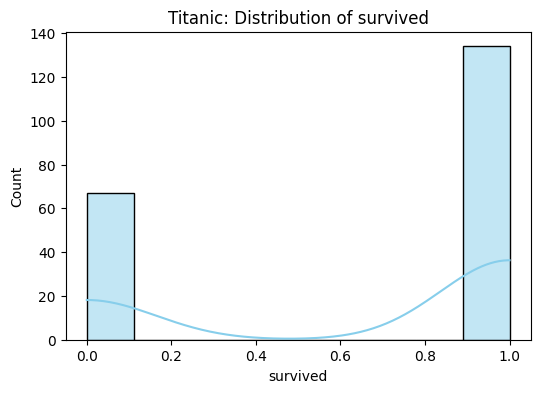

Insight 1: The histogram shows the frequency distribution and central tendency of 'survived'.


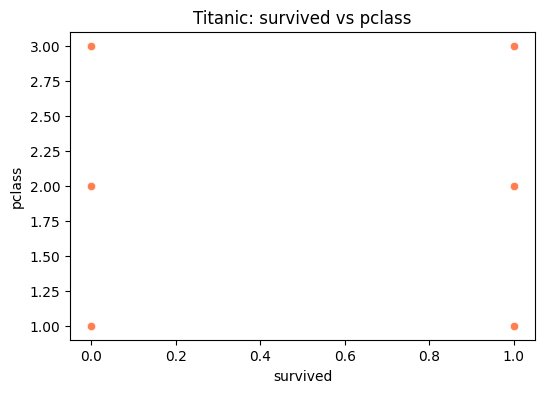

Insight 2: The scatter plot helps visualize the correlation and outliers between 'survived' and 'pclass'.

=============== TIPS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


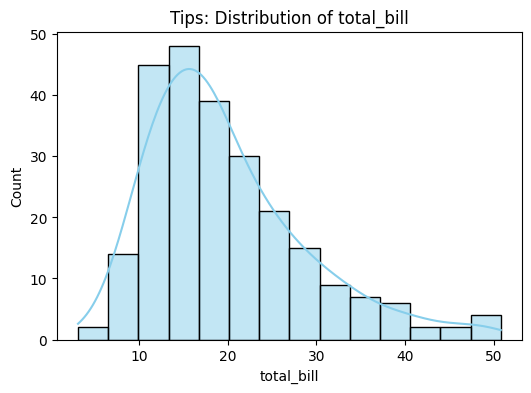

Insight 1: The histogram shows the frequency distribution and central tendency of 'total_bill'.


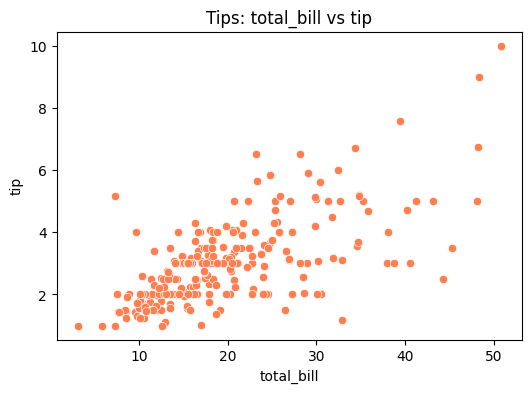

Insight 2: The scatter plot helps visualize the correlation and outliers between 'total_bill' and 'tip'.

=============== IRIS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


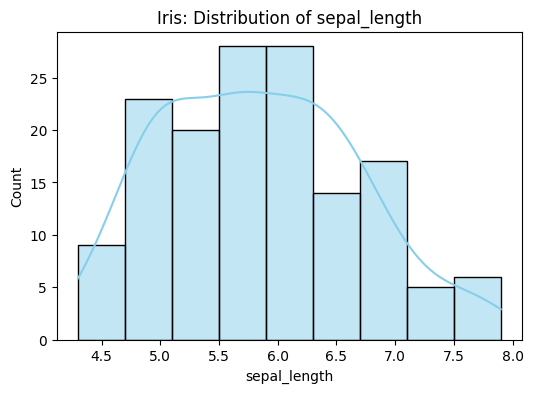

Insight 1: The histogram shows the frequency distribution and central tendency of 'sepal_length'.


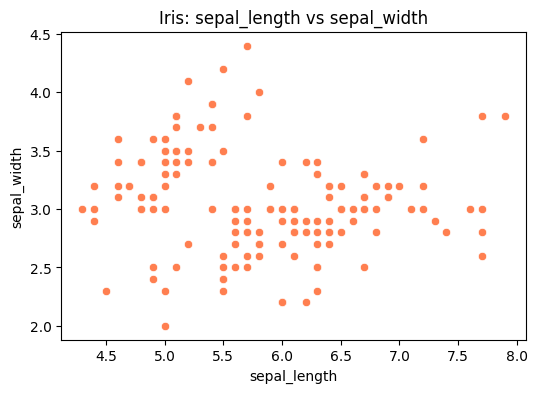

Insight 2: The scatter plot helps visualize the correlation and outliers between 'sepal_length' and 'sepal_width'.

=============== PENGUINS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


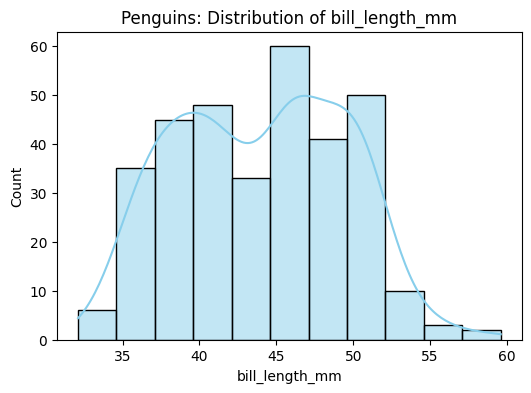

Insight 1: The histogram shows the frequency distribution and central tendency of 'bill_length_mm'.


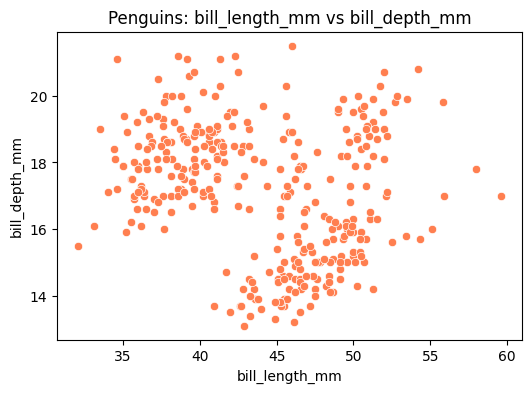

Insight 2: The scatter plot helps visualize the correlation and outliers between 'bill_length_mm' and 'bill_depth_mm'.

=============== DIAMONDS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


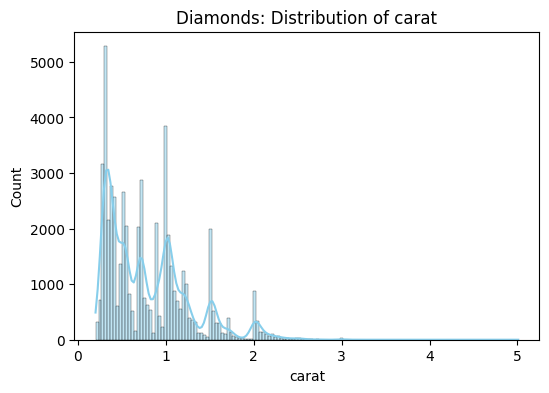

Insight 1: The histogram shows the frequency distribution and central tendency of 'carat'.


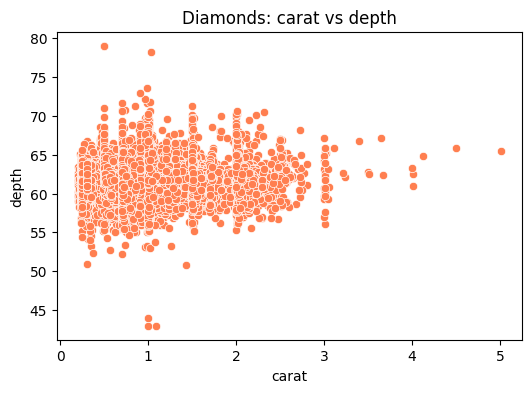

Insight 2: The scatter plot helps visualize the correlation and outliers between 'carat' and 'depth'.

=============== MPG DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


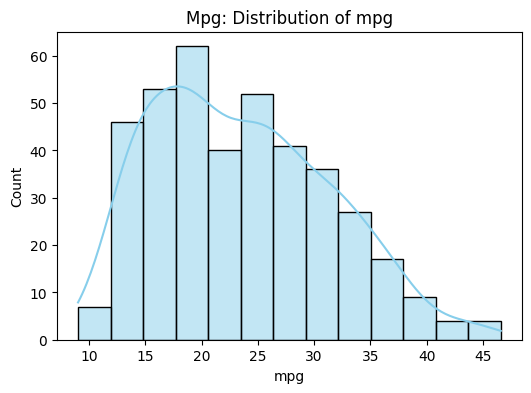

Insight 1: The histogram shows the frequency distribution and central tendency of 'mpg'.


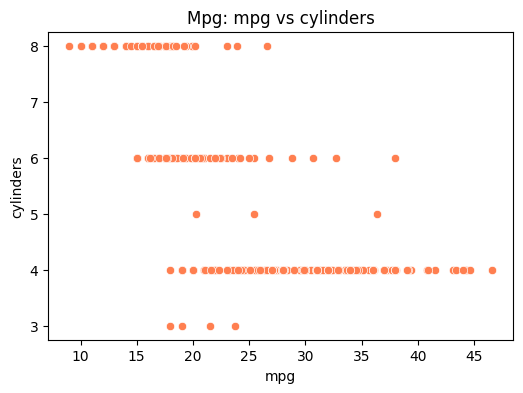

Insight 2: The scatter plot helps visualize the correlation and outliers between 'mpg' and 'cylinders'.

=============== TAXIS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


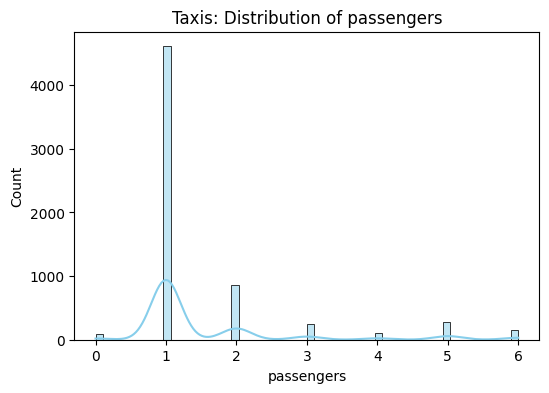

Insight 1: The histogram shows the frequency distribution and central tendency of 'passengers'.


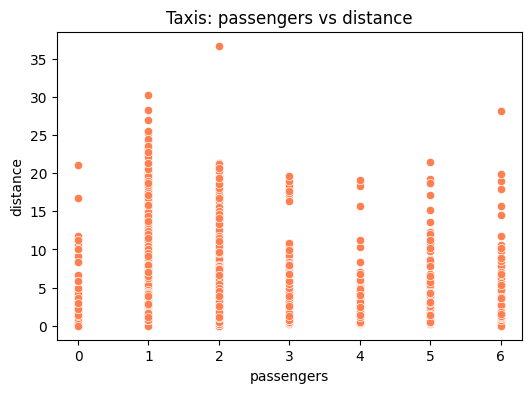

Insight 2: The scatter plot helps visualize the correlation and outliers between 'passengers' and 'distance'.

=============== PLANETS DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


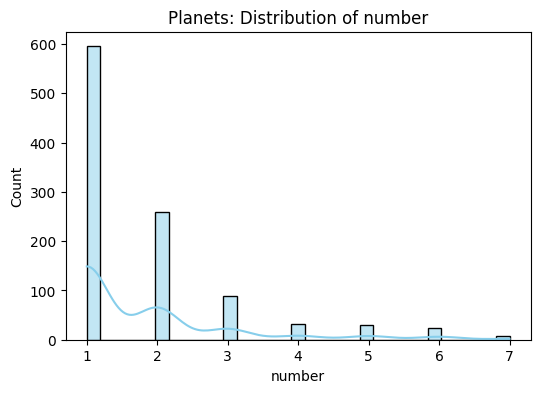

Insight 1: The histogram shows the frequency distribution and central tendency of 'number'.


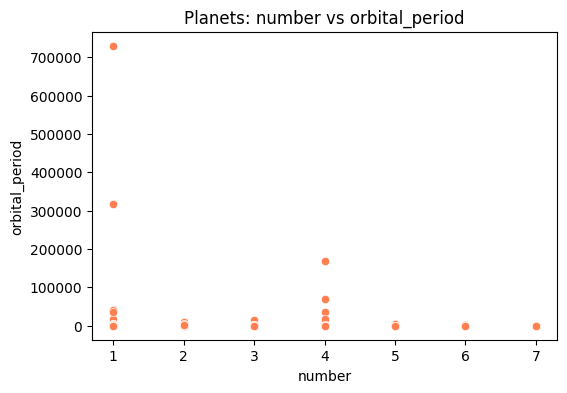

Insight 2: The scatter plot helps visualize the correlation and outliers between 'number' and 'orbital_period'.

=============== CAR_CRASHES DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


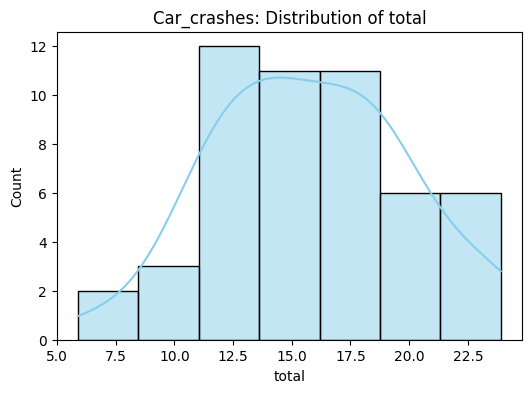

Insight 1: The histogram shows the frequency distribution and central tendency of 'total'.


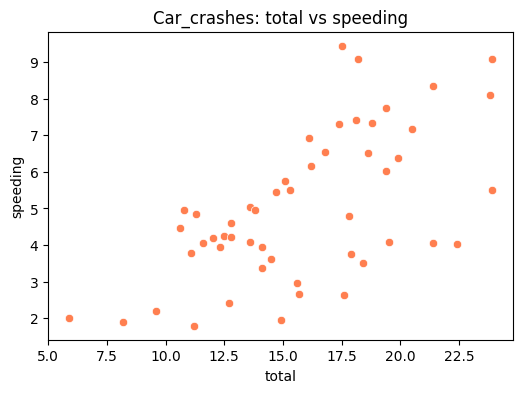

Insight 2: The scatter plot helps visualize the correlation and outliers between 'total' and 'speeding'.

=============== GEYSER DATASET ===============
Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.


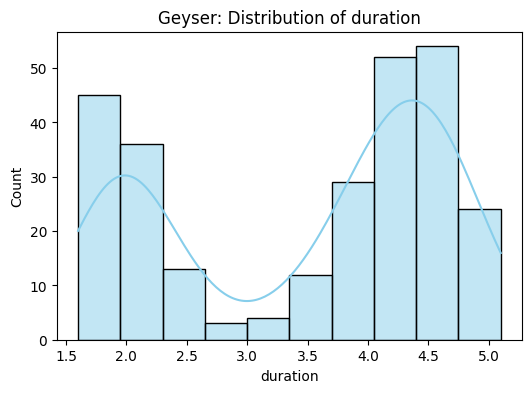

Insight 1: The histogram shows the frequency distribution and central tendency of 'duration'.


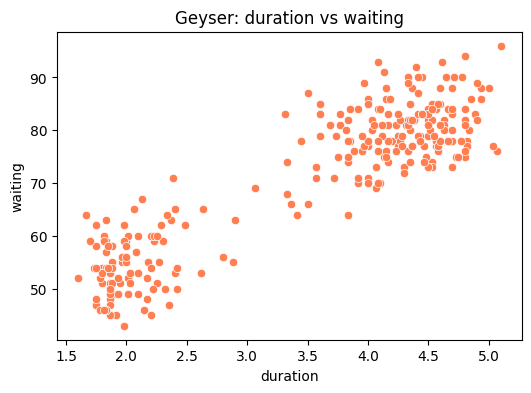

Insight 2: The scatter plot helps visualize the correlation and outliers between 'duration' and 'waiting'.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

datasets = [
    'titanic', 'tips', 'iris', 'penguins', 'diamonds',
    'mpg', 'taxis', 'planets', 'car_crashes', 'geyser'
]

for name in datasets:
    df = sns.load_dataset(name)

    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].mean())
    df = df.dropna()

    print(f"\n{'='*15} {name.upper()} DATASET {'='*15}")
    print("Data Cleaning Done: Numerical NaNs filled with mean, other NaNs dropped.")

    plt.figure(figsize=(6, 4))
    sns.histplot(df[num_cols[0]], kde=True, color='skyblue')
    plt.title(f"{name.capitalize()}: Distribution of {num_cols[0]}")
    plt.show()

    print(f"Insight 1: The histogram shows the frequency distribution and central tendency of '{num_cols[0]}'.")

    if len(num_cols) > 1:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]], color='coral')
        plt.title(f"{name.capitalize()}: {num_cols[0]} vs {num_cols[1]}")
        plt.show()

        print(f"Insight 2: The scatter plot helps visualize the correlation and outliers between '{num_cols[0]}' and '{num_cols[1]}'.")